# Pre-EFA Assumption Checks

Runs all pre-EFA diagnostics. Paths are resolved relative to this notebook's location.

**Pre-EFA:** sample size, correlation matrix, normality, outliers, and KMO & Bartlett's  


In [1]:
import warnings
warnings.filterwarnings('ignore', message='IProgress not found')  # tqdm/ipywidgets nag, not informative
warnings.filterwarnings('ignore', message='.*Moore-Penrose.*')    # factor_analyzer notes this; we check the determinant explicitly below

from pathlib import Path
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from langdetect import detect, LangDetectException
from collections import defaultdict
from sklearn.preprocessing import PowerTransformer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import joblib

from ep_pipeline.config import MetricsConfig
from ep_pipeline.io import load_csv, write_table
from ep_pipeline.efa.efa import prepare_features, scale_metrics, parallel_analysis, plot_scree, fit_efa
from ep_pipeline.efa.metric_taxonomy import CATEGORY_OF

## Removing noisy data

In [2]:
PROJECT_ROOT = Path.cwd().parent  # nbs/ is one level under chr_stability_paper/
TEXT_FP_DETECT = PROJECT_ROOT / 'data' / 'human_texts_2023_2025.csv'
CHR27_FP       = PROJECT_ROOT / 'data' / 'data_subset_chr27.csv'

# Prefer the freshly-scored AO3metrics_full.csv (produced by run_AO3_scoring.py);
# fall back to the bundled, anonymized final_full_dataset.csv so this notebook
# also runs without the scoring pipeline having been run first.
_SCORED_FP   = PROJECT_ROOT / 'data' / 'AO3metrics_full.csv'
_FALLBACK_FP = PROJECT_ROOT / 'data' / 'final_full_dataset.csv'
IN_FP        = _SCORED_FP if _SCORED_FP.exists() else _FALLBACK_FP

VIS_DIR     = PROJECT_ROOT / 'outputs' / 'visualizations'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'efa_assumptions'
VIS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cfg = MetricsConfig()
random.seed(2001)

In [3]:
if IN_FP == _FALLBACK_FP:
    print(f"NOTE: {_SCORED_FP.name} not found - using the anonymized {IN_FP.name} instead.")
    print("This runs the checks below on the already-cleaned/transformed feature set")
    print("(fewer variables, already winsorized and normalized) rather than the original")
    print("raw 110-variable metric set. Run run_AO3_scoring.py first for the full")
    print("from-scratch diagnostics.\n")
else:
    print(f"Using freshly-scored {IN_FP.name}.\n")

NOTE: AO3metrics_full.csv not found - using the anonymized final_full_dataset.csv instead.
This runs the checks below on the already-cleaned/transformed feature set
(fewer variables, already winsorized and normalized) rather than the original
raw 110-variable metric set. Run run_AO3_scoring.py first for the full
from-scratch diagnostics.



In [4]:
CLEANED_FP = PROJECT_ROOT / 'data' / 'all_metrics_cleaned.csv'

if CLEANED_FP.exists():
    all_metrics = pd.read_csv(CLEANED_FP)
    print(f"Loaded cached cleaned data → {CLEANED_FP.relative_to(PROJECT_ROOT)}  ({len(all_metrics):,} rows)")
    print("The detection/filtering cells below will detect the cache and skip themselves.")
else:
    all_metrics = None
    print("No cache found — run the detection/filtering cells below; they'll save the cache at the end.")

No cache found — run the detection/filtering cells below; they'll save the cache at the end.


In [5]:
if all_metrics is None:
    # Mirror the combine step in run_AO3_scoring.py so detection covers the full dataset
    _texts_full  = pd.read_csv(TEXT_FP_DETECT, usecols=['work_id', 'text'])
    _texts_chr27 = pd.read_csv(CHR27_FP,       usecols=['work_id', 'text'])
    texts = (
        pd.concat([_texts_full, _texts_chr27], ignore_index=True)
        .rename(columns={'work_id': 'id'})
        .dropna(subset=['text'])
    )

    meta = pd.read_csv(IN_FP, usecols=['id', 'title', 'author', 'fandom', 'words'])

    def safe_detect(text, chars=10000):
        try:
            return detect(str(text)[:chars])
        except LangDetectException:
            return 'unknown'

    texts['lang'] = texts['text'].apply(safe_detect)

    flagged = (
        texts[texts['lang'] != 'en']
        .merge(meta, on='id', how='inner')
        .sort_values('words', ascending=False)
    )
    NON_ENGLISH_DETECTED = set(flagged['id'])

    print(f"Flagged {len(NON_ENGLISH_DETECTED)} non-English texts — inspect, then run next cell\n")
    for i, row in flagged.iterrows():
        print(f"{'─'*60}")
        print(f"id={row['id']}  lang={row['lang']}  words={int(row['words'])}")
        print(f"  title : {row['title']}")
        print(f"  author: {row['author']}")
        print(f"  fandom: {row['fandom']}")
        print()
else:
    print("Using cached cleaned data — skipping non-English detection.")

Flagged 0 non-English texts — inspect, then run next cell



In [6]:
if all_metrics is None:
    all_metrics = load_csv(IN_FP).drop_duplicates(subset='id').reset_index(drop=True)

    # If IN_FP is the anonymized fallback, it already has F1-F10 from a previous EFA
    # run - those are outputs, not raw metrics, and would otherwise get swept into
    # meta_full as pass-through columns and collide with the fresh scores fit_efa_AO3.ipynb
    # computes downstream. Drop them so this always starts from a clean slate.
    _stale_factor_cols = [c for c in all_metrics.columns if c.startswith('F') and c[1:].isdigit()]
    if _stale_factor_cols:
        all_metrics = all_metrics.drop(columns=_stale_factor_cols)
        print(f"Dropped pre-existing factor-score columns from fallback input: {_stale_factor_cols}")

    exclude = NON_ENGLISH_DETECTED
    all_metrics = all_metrics[~all_metrics['id'].isin(exclude)].reset_index(drop=True)
    print(f"Excluded {len(exclude)} non-English texts "
          f" → {len(all_metrics)} remaining")
else:
    print("Using cached cleaned data — skipping non-English exclusion.")

Dropped pre-existing factor-score columns from fallback input: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10']
Excluded 0 non-English texts  → 16966 remaining


In [7]:
dupes = all_metrics[all_metrics.duplicated(subset='id', keep=False)].sort_values('id')

exact = all_metrics.duplicated(keep=False)
print(f"Exact duplicate rows : {exact.sum()}")
print(f"Same ID, diff values : {len(dupes) - exact[dupes.index].sum()}")


Exact duplicate rows : 0
Same ID, diff values : 0


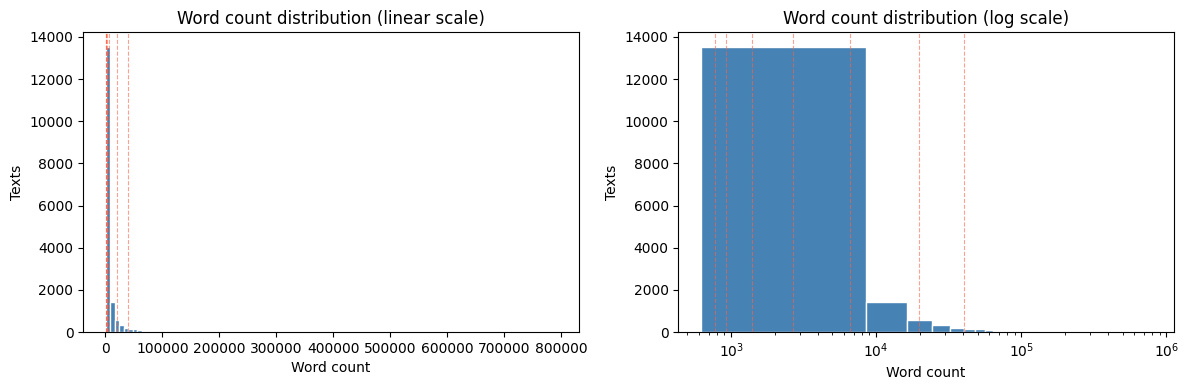

  Percentile     Words
────────────────────────
          5th       779
         10th       930
         25th     1,387
         50th     2,662
         75th     6,605
         90th    19,778
         95th    40,146
────────────────────────
         Min       619
        Mean     9,697
         Max   791,104


In [8]:
words = all_metrics['words'].dropna()
pcts  = [5, 10, 25, 50, 75, 90, 95]
vals  = np.percentile(words, pcts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, xscale in zip(axes, ['linear', 'log']):
    ax.hist(words, bins=100, color='steelblue', edgecolor='white')
    for v in vals:
        ax.axvline(v, color='tomato', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Texts')
    ax.set_xscale(xscale)
    ax.set_title(f'Word count distribution ({xscale} scale)')
plt.tight_layout()
plt.savefig(VIS_DIR / 'word_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Percentile':>12}  {'Words':>8}")
print('─' * 24)
for p, v in zip(pcts, vals):
    print(f"{p:>11}th  {v:>8,.0f}")
print('─' * 24)
print(f"{'Min':>12}  {words.min():>8,.0f}")
print(f"{'Mean':>12}  {words.mean():>8,.0f}")
print(f"{'Max':>12}  {words.max():>8,.0f}")

In [9]:
if not CLEANED_FP.exists():
    # 619 was chosen by the pre-filter word-count distribution above (trims the very shortest, likely-noisy texts)
    MIN_WORDS = 619

    n_before    = len(all_metrics)
    all_metrics = all_metrics[all_metrics['words'] >= MIN_WORDS].reset_index(drop=True)
    n_removed   = n_before - len(all_metrics)
    print(f"Minimum length : {MIN_WORDS} words")
    print(f"Removed        : {n_removed} texts  ({100 * n_removed / n_before:.1f}%)")
    print(f"Remaining      : {len(all_metrics)} texts")

    all_metrics.to_csv(CLEANED_FP, index=False)
    print(f"\nSaved cleaned data → {CLEANED_FP.relative_to(PROJECT_ROOT)}")
else:
    print(f"Using cached cleaned data ({len(all_metrics)} texts) — cache already at {CLEANED_FP.relative_to(PROJECT_ROOT)}")

Minimum length : 619 words
Removed        : 0 texts  (0.0%)
Remaining      : 16966 texts



Saved cleaned data → data/all_metrics_cleaned.csv


In [10]:
feat_df, feature_cols, final_category_map, meta_df = prepare_features(
    all_metrics, CATEGORY_OF, set()
)

zero_var = [c for c in feature_cols if feat_df[c].std() == 0]
if zero_var:
    print(f"Dropping {len(zero_var)} zero-variance variable(s): {zero_var}")
    feat_df            = feat_df.drop(columns=zero_var)
    feature_cols       = [c for c in feature_cols if c not in zero_var]
    final_category_map = {k: v for k, v in final_category_map.items() if k in feature_cols}

meta_full      = all_metrics[[c for c in all_metrics.columns if c not in set(feature_cols) and c != 'text']]
scaled_metrics, scaler = scale_metrics(feat_df)
n_obs, n_vars  = scaled_metrics.shape
corr           = np.corrcoef(scaled_metrics, rowvar=False)
print(f'Loaded: {n_obs} observations x {n_vars} variables')

Dropping 1 zero-variance variable(s): ['syllables_per_token_median']
Loaded: 16966 observations x 71 variables


## 1. Sample size

Thresholds: `N > 150` and `N/variable >= 5` (ideally >= 20).

In [11]:
ratio   = n_obs / n_vars
n_pass  = 'PASS' if n_obs > 150 else 'FAIL — need >150'
r_pass  = 'PASS' if ratio >= 5  else 'FAIL — need >=5'
r2_pass = 'PASS' if ratio >= 20 else 'NOTE — ideally >=20'
print(f'N observations  : {n_obs}  ({n_pass})')
print(f'N variables     : {n_vars}')
print(f'N/variable ratio: {ratio:.1f}  ({r_pass} / {r2_pass})')

N observations  : 16966  (PASS)
N variables     : 71
N/variable ratio: 239.0  (PASS / PASS)


## 2. Correlation matrix

- Pairs with `|r| > 0.8`: multicollinearity — remove one from the pair  
- Items where max `|r| < 0.3`: too weakly correlated with everything — consider removing  
- Determinant > 1e-5: required for matrix inversion in EFA

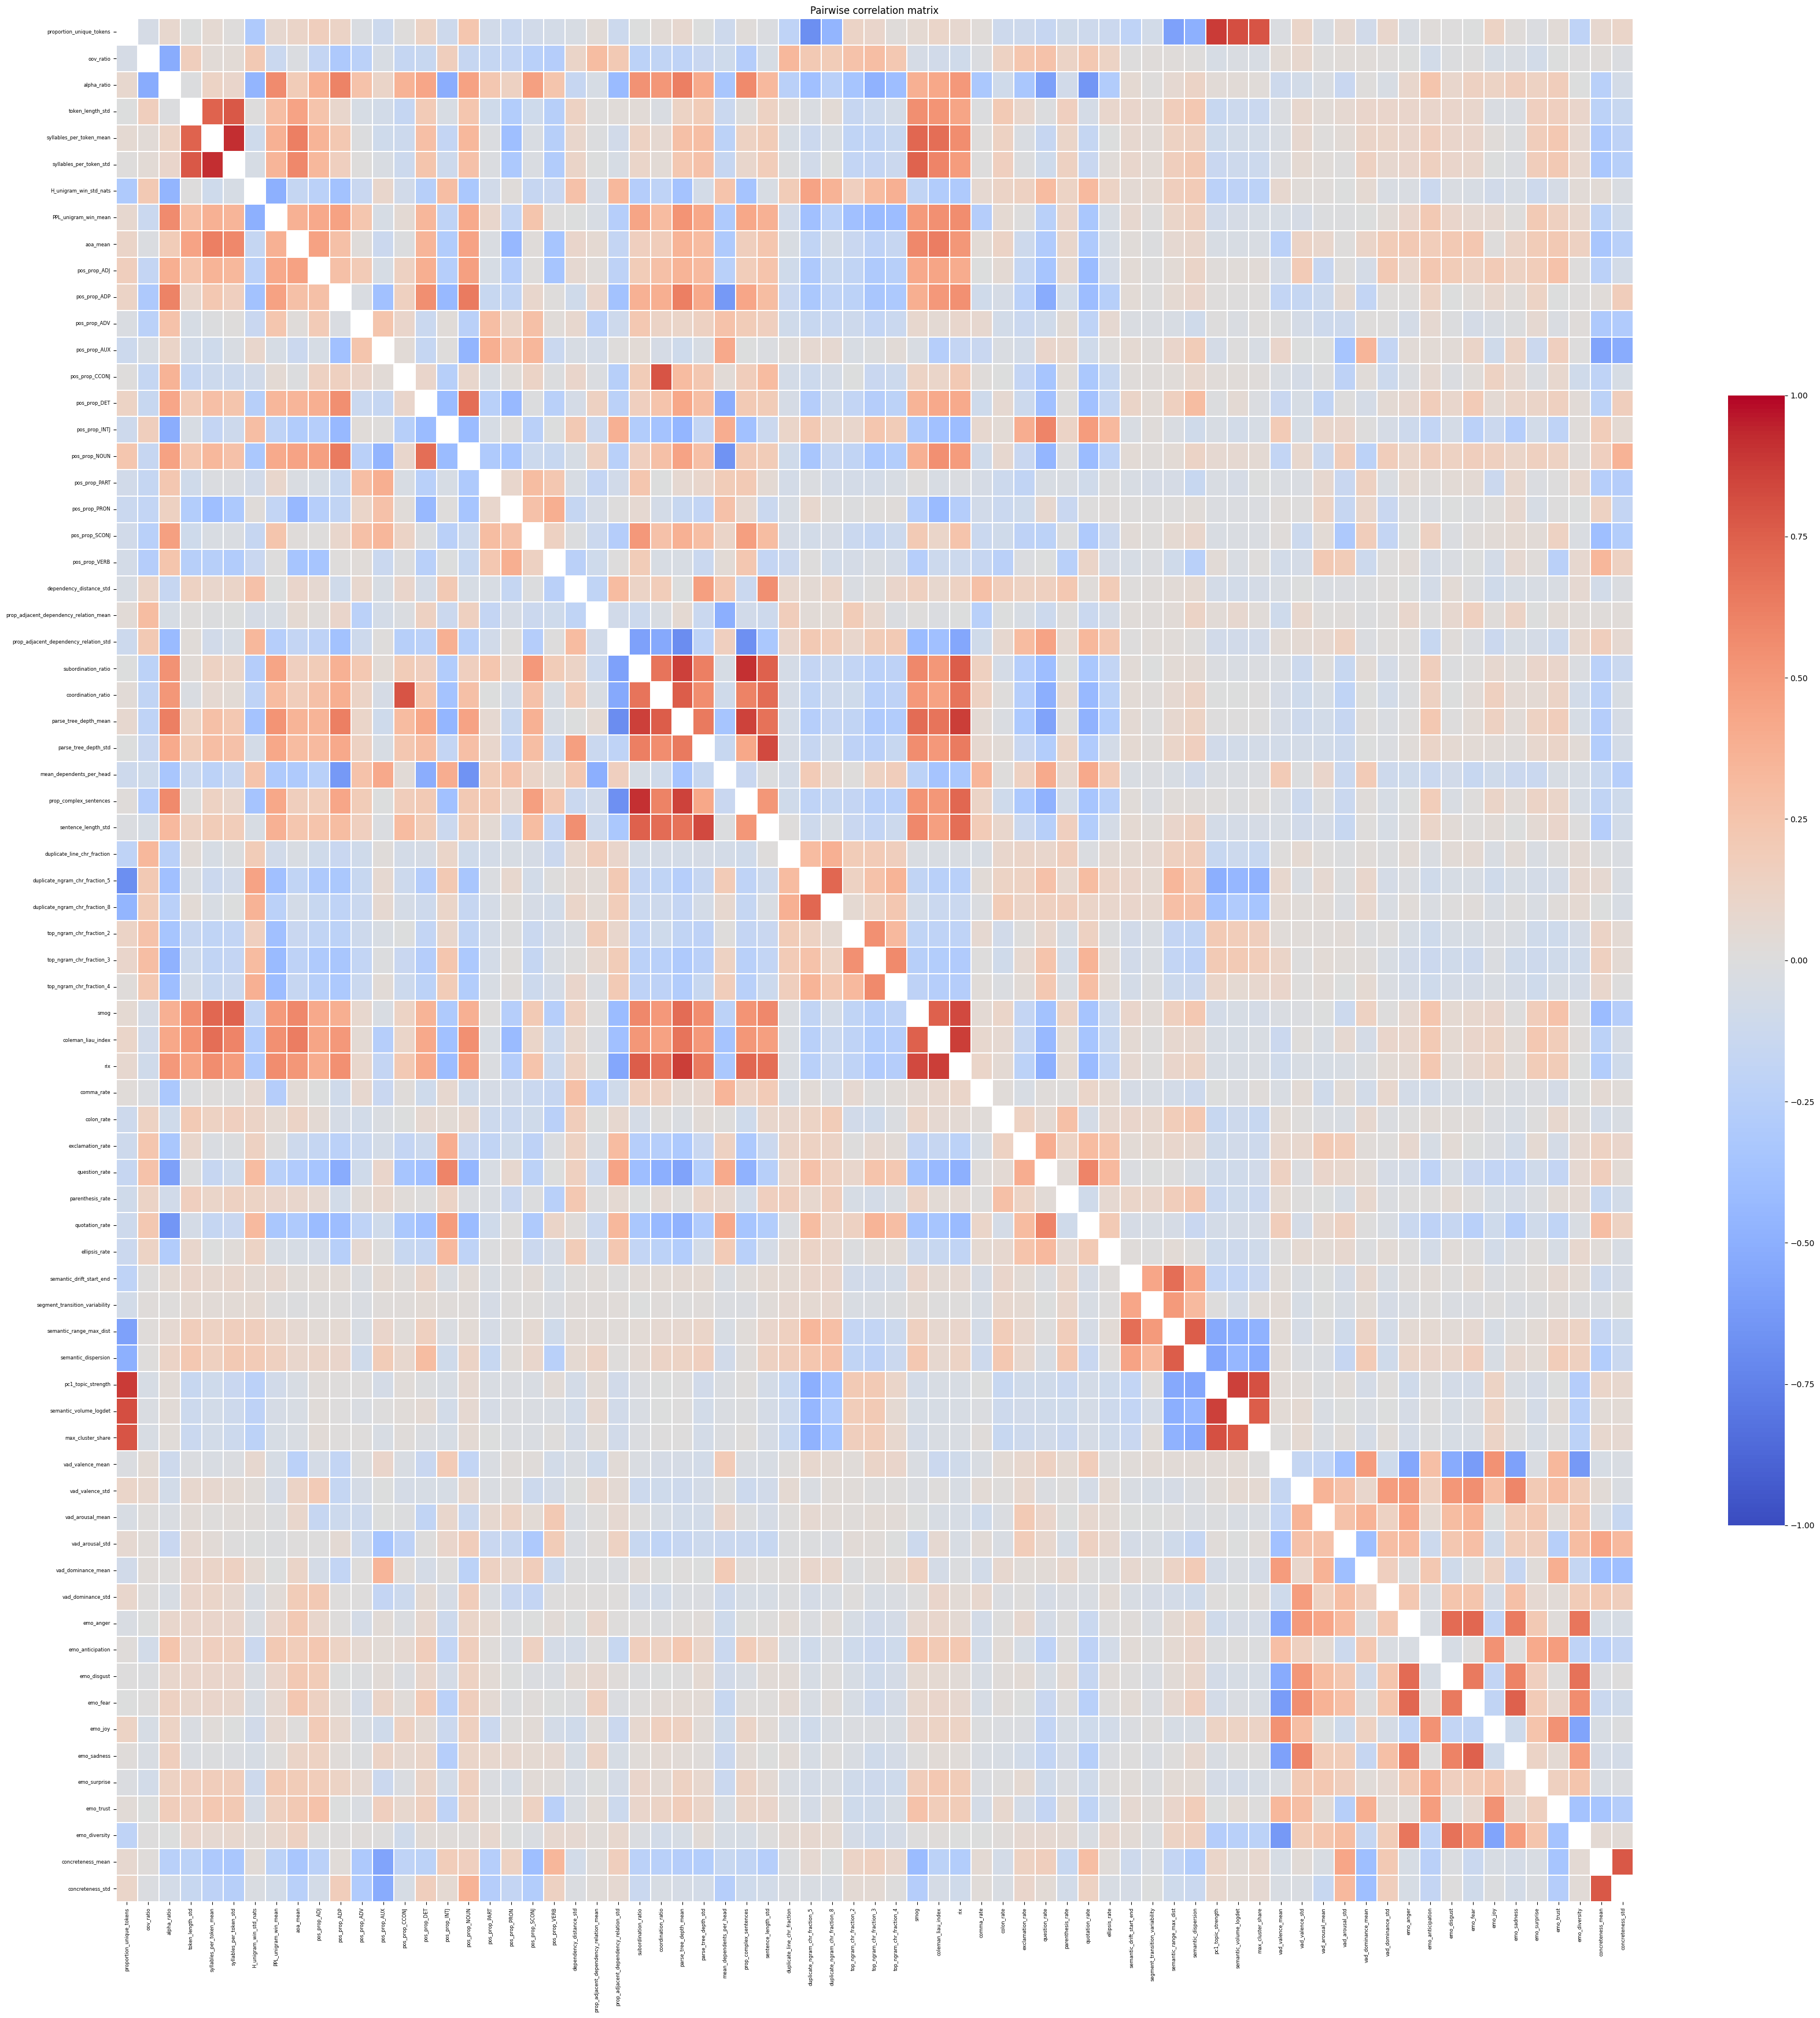

In [12]:
fig_w = max(10, n_vars // 2)
fig_h = max(8,  n_vars // 2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
mask = np.eye(n_vars, dtype=bool)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=feature_cols, yticklabels=feature_cols,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title('Pairwise correlation matrix')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
upper    = np.triu(np.abs(corr), k=1)
mc_pairs = [
    (feature_cols[i], feature_cols[j], corr[i, j])
    for i, j in zip(*np.where(upper > 0.8))
]
print(f'Multicollinearity (|r| > 0.8): {len(mc_pairs)} pair(s)')
for a, b, r in mc_pairs:
    print(f'  {a} <-> {b}:  r = {r:.3f}')

off_diag = np.abs(corr - np.eye(n_vars))
max_r    = off_diag.max(axis=1)
weak     = [(feature_cols[i], max_r[i]) for i in range(n_vars) if max_r[i] < 0.3]
print(f'\nWeak correlators (max |r| < 0.3): {len(weak)} variable(s)')
for name, r in weak:
    print(f'  {name}:  max |r| = {r:.3f}')

det      = np.linalg.det(corr)
det_pass = 'PASS' if det > 1e-5 else 'FAIL — near-singular'
print(f'\nDeterminant: {det:.2e}  ({det_pass})')

mc_df   = pd.DataFrame(mc_pairs, columns=['variable_a', 'variable_b', 'r']) if mc_pairs else pd.DataFrame(columns=['variable_a', 'variable_b', 'r'])
weak_df = pd.DataFrame(weak, columns=['variable', 'max_r']) if weak else pd.DataFrame(columns=['variable', 'max_r'])
write_table(mc_df,   RESULTS_DIR / 'corr_multicollinearity.csv')
write_table(weak_df, RESULTS_DIR / 'corr_weak_variables.csv')

Multicollinearity (|r| > 0.8): 12 pair(s)
  proportion_unique_tokens <-> pc1_topic_strength:  r = 0.875
  proportion_unique_tokens <-> semantic_volume_logdet:  r = 0.820
  syllables_per_token_mean <-> syllables_per_token_std:  r = 0.920
  subordination_ratio <-> parse_tree_depth_mean:  r = 0.860
  subordination_ratio <-> prop_complex_sentences:  r = 0.912
  parse_tree_depth_mean <-> prop_complex_sentences:  r = 0.855
  parse_tree_depth_mean <-> rix:  r = 0.872
  parse_tree_depth_std <-> sentence_length_std:  r = 0.830
  smog <-> rix:  r = 0.833
  coleman_liau_index <-> rix:  r = 0.869
  pc1_topic_strength <-> semantic_volume_logdet:  r = 0.864
  pc1_topic_strength <-> max_cluster_share:  r = 0.806

Weak correlators (max |r| < 0.3): 2 variable(s)
  colon_rate:  max |r| = 0.278
  parenthesis_rate:  max |r| = 0.278

Determinant: 1.31e-29  (FAIL — near-singular)


In [14]:
rows = []
for i, (a, b, r_ab) in enumerate(mc_pairs, 1):
    others  = [c for c in feature_cols if c not in (a, b)]
    idx_a   = feature_cols.index(a)
    idx_b   = feature_cols.index(b)
    idx_o   = [feature_cols.index(c) for c in others]
    reach_a = np.nanmean(np.abs(corr[idx_a][idx_o]))
    reach_b = np.nanmean(np.abs(corr[idx_b][idx_o]))
    keep    = a if reach_a >= reach_b else b
    drop    = b if keep == a else a

    print(f"Pair {i}/{len(mc_pairs)}:  {a}  <->  {b}  (r = {r_ab:.3f})")
    print(f"  {a:<50}  reach = {reach_a:.3f}")
    print(f"  {b:<50}  reach = {reach_b:.3f}")
    print(f"  --> KEEP: {keep}")
    print(f"      DROP: {drop}")
    print()

    rows.append({
        'variable_a': a, 'variable_b': b, 'r': round(r_ab, 3),
        'reach_a': round(reach_a, 3), 'reach_b': round(reach_b, 3),
        'recommended_keep': keep, 'recommended_drop': drop,
    })

mc_recommendation_df = pd.DataFrame(rows)
write_table(mc_recommendation_df, RESULTS_DIR / 'corr_multicollinearity_recommendations.csv')
print(f"Saved recommendations for {len(rows)} pair(s).")

Pair 1/12:  proportion_unique_tokens  <->  pc1_topic_strength  (r = 0.875)
  proportion_unique_tokens                            reach = 0.132
  pc1_topic_strength                                  reach = 0.117
  --> KEEP: proportion_unique_tokens
      DROP: pc1_topic_strength

Pair 2/12:  proportion_unique_tokens  <->  semantic_volume_logdet  (r = 0.820)
  proportion_unique_tokens                            reach = 0.133
  semantic_volume_logdet                              reach = 0.107
  --> KEEP: proportion_unique_tokens
      DROP: semantic_volume_logdet

Pair 3/12:  syllables_per_token_mean  <->  syllables_per_token_std  (r = 0.920)
  syllables_per_token_mean                            reach = 0.170
  syllables_per_token_std                             reach = 0.158
  --> KEEP: syllables_per_token_mean
      DROP: syllables_per_token_std

Pair 4/12:  subordination_ratio  <->  parse_tree_depth_mean  (r = 0.860)
  subordination_ratio                                 reach = 0.205
 

**Greedy resolution strategy:** among variables still tangled in an |r| > 0.8 pair, repeatedly drop whichever one is involved in the most remaining collinear pairs; ties are broken by dropping the one with the lower average |r| ('reach') against the rest of the variable set, i.e. keep whichever of the pair is more broadly informative. Repeat until no collinear pairs remain.


In [15]:
# Build adjacency list from collinear pairs
neighbours = defaultdict(set)
for a, b, _ in mc_pairs:
    neighbours[a].add(b)
    neighbours[b].add(a)

remaining = set(feature_cols)
to_drop   = set()

while True:
    # Find all edges that still exist among remaining variables
    active_edges = [
        (a, b) for a, b, _ in mc_pairs
        if a in remaining and b in remaining
    ]
    if not active_edges:
        break

    # Count collinear neighbours still in play for each variable
    degree = defaultdict(int)
    for a, b in active_edges:
        degree[a] += 1
        degree[b] += 1

    # Drop the variable with the most collinear neighbours and break ties by choosing the one with the lower reach
    max_deg  = max(degree.values())
    tied     = [v for v, d in degree.items() if d == max_deg]
    idx_map  = {c: i for i, c in enumerate(feature_cols)}
    drop_var = min(tied, key=lambda v: np.nanmean(np.abs(corr[idx_map[v]][[idx_map[c] for c in feature_cols if c != v]])))

    to_drop.add(drop_var)
    remaining.discard(drop_var)

print(f"Variables to drop  : {len(to_drop)}")
print(f"Variables to keep  : {len(remaining)}")
print(f"\nDROP ({len(to_drop)}):")
for v in sorted(to_drop):
    print(f"  {v}")

drop_df = pd.DataFrame(sorted(to_drop), columns=['variable'])
write_table(drop_df, RESULTS_DIR / 'collinearity_drop_list.csv')

Variables to drop  : 7
Variables to keep  : 64

DROP (7):
  parse_tree_depth_mean
  pc1_topic_strength
  rix
  semantic_volume_logdet
  sentence_length_std
  subordination_ratio
  syllables_per_token_std


In [16]:
idx_map_all  = {c: i for i, c in enumerate(feature_cols)}
reach_all    = {
    v: np.nanmean(np.abs(corr[idx_map_all[v]][[idx_map_all[c] for c in feature_cols if c != v]]))
    for v in feature_cols
}
orig_degree = defaultdict(int)
for a, b, _ in mc_pairs:
    orig_degree[a] += 1
    orig_degree[b] += 1

summary_df = pd.DataFrame([{
    'variable':        v,
    'category':        CATEGORY_OF.get(v, 'unknown'),
    'status':          'DROP' if v in to_drop else 'KEEP',
    'reach':           round(reach_all[v], 3),
    'collinear_pairs': orig_degree.get(v, 0),
} for v in feature_cols]).sort_values(
    ['category', 'status', 'reach'], ascending=[True, True, False]
)

for cat, grp in summary_df.groupby('category'):
    n_keep = (grp['status'] == 'KEEP').sum()
    n_drop = (grp['status'] == 'DROP').sum()
    print(f"\n{'='*65}")
    print(f"  {cat}  —  keep {n_keep}  /  drop {n_drop}")
    print(f"{'='*65}")
    print(grp[['status', 'variable', 'reach', 'collinear_pairs']].to_string(index=False))

write_table(summary_df, RESULTS_DIR / 'collinearity_summary_by_category.csv')


  Affect Dimensions  —  keep 6  /  drop 0
status           variable  reach  collinear_pairs
  KEEP   vad_valence_mean  0.133                0
  KEEP    vad_arousal_std  0.130                0
  KEEP    vad_valence_std  0.113                0
  KEEP vad_dominance_mean  0.105                0
  KEEP   vad_arousal_mean  0.091                0
  KEEP  vad_dominance_std  0.087                0

  Clustering & Diversity  —  keep 1  /  drop 0
status          variable  reach  collinear_pairs
  KEEP max_cluster_share  0.116                1

  Coherence & Trajectory  —  keep 3  /  drop 0
status                       variable  reach  collinear_pairs
  KEEP        semantic_range_max_dist  0.138                0
  KEEP       semantic_drift_start_end  0.078                0
  KEEP segment_transition_variability  0.045                0

  Concreteness & Imagery  —  keep 2  /  drop 0
status          variable  reach  collinear_pairs
  KEEP concreteness_mean  0.182                0
  KEEP  concretenes

In [17]:
if 'n_tokens' in all_metrics.columns:
    n_tokens_vals = all_metrics['n_tokens'].values
    length_corr = pd.Series(
        {col: np.corrcoef(feat_df[col].values, n_tokens_vals)[0, 1] for col in feature_cols},
        name='r_with_n_tokens'
    ).sort_values(key=abs, ascending=False)

    print(length_corr.head(10).to_string())
else:
    print("'n_tokens' not in this feature set (dropped upstream in the anonymized "
          "fallback data) - skipping length-correlation check.")

'n_tokens' not in this feature set (dropped upstream in the anonymized fallback data) - skipping length-correlation check.


### Manual overrides to drop list 

In [18]:
# weak correlators (max |r| < 0.3) — no real signal to contribute
force_drop = {'pos_prop_X', 'pos_prop_NUM', 'pos_prop_SYM', 'PPL_3gram_self_nats'}

# algorithm auto-DROP'd them, but reach/pairs alone isn't the full story
force_rescue = {'semantic_volume_logdet', 'prop_complex_sentences'}


to_drop = (to_drop | force_drop) - force_rescue

print("Manual overrides applied:")
print(f"  Added to drop    : {sorted(force_drop)}")
print(f"  Rescued from drop: {sorted(force_rescue)}")
print(f"\nFinal drop count : {len(to_drop)}")
print(f"Final keep count : {len(feature_cols) - len(to_drop)}")

Manual overrides applied:
  Added to drop    : ['PPL_3gram_self_nats', 'pos_prop_NUM', 'pos_prop_SYM', 'pos_prop_X']
  Rescued from drop: ['prop_complex_sentences', 'semantic_volume_logdet']

Final drop count : 10
Final keep count : 61


In [19]:
# Apply collinearity drop list — create cleaned variable set for KMO and beyond
keep_cols      = [c for c in feature_cols if c not in to_drop]
keep_idx       = [feature_cols.index(c) for c in keep_cols]
scaled_clean   = scaled_metrics[:, keep_idx]
category_clean = {c: final_category_map[c] for c in keep_cols}
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

det_clean = np.linalg.det(corr_clean)
print(f"Variables after collinearity resolution : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")

Variables after collinearity resolution : 65
Determinant (cleaned matrix)            : 1.94e-22


## 3. Normality

EFA is robust to mild non-normality. Flag variables with `|skew| > 2` or `|kurt| > 7`; consider log or sqrt transformation if needed.

In [20]:
norm_df = pd.DataFrame({
    'skewness': stats.skew(scaled_clean),
    'kurtosis': stats.kurtosis(scaled_clean),
}, index=keep_cols).sort_values('skewness', key=abs, ascending=False)

flagged = norm_df[(norm_df['skewness'].abs() > 2) | (norm_df['kurtosis'].abs() > 7)]
print(f'Variables flagged (|skew|>2 or |kurt|>7): {len(flagged)}')
print(norm_df.to_string())

Variables flagged (|skew|>2 or |kurt|>7): 0
                                        skewness  kurtosis
duplicate_line_chr_fraction             1.940616  2.793276
emo_joy                                 0.941519  1.181872
semantic_volume_logdet                  0.884219 -0.706202
duplicate_ngram_chr_fraction_8          0.851329 -0.612381
colon_rate                              0.776779 -0.806766
emo_trust                               0.740809  1.166203
parenthesis_rate                        0.722060 -1.001169
smog                                    0.705646  1.120850
quotation_rate                          0.553683  0.302447
max_cluster_share                       0.531247 -0.242088
segment_transition_variability          0.526415  1.622916
pos_prop_CCONJ                          0.491216  0.661178
pos_prop_SCONJ                          0.454184  0.706377
pos_prop_ADJ                            0.438769  0.723278
aoa_mean                                0.430914  0.780454
pos_prop_DET

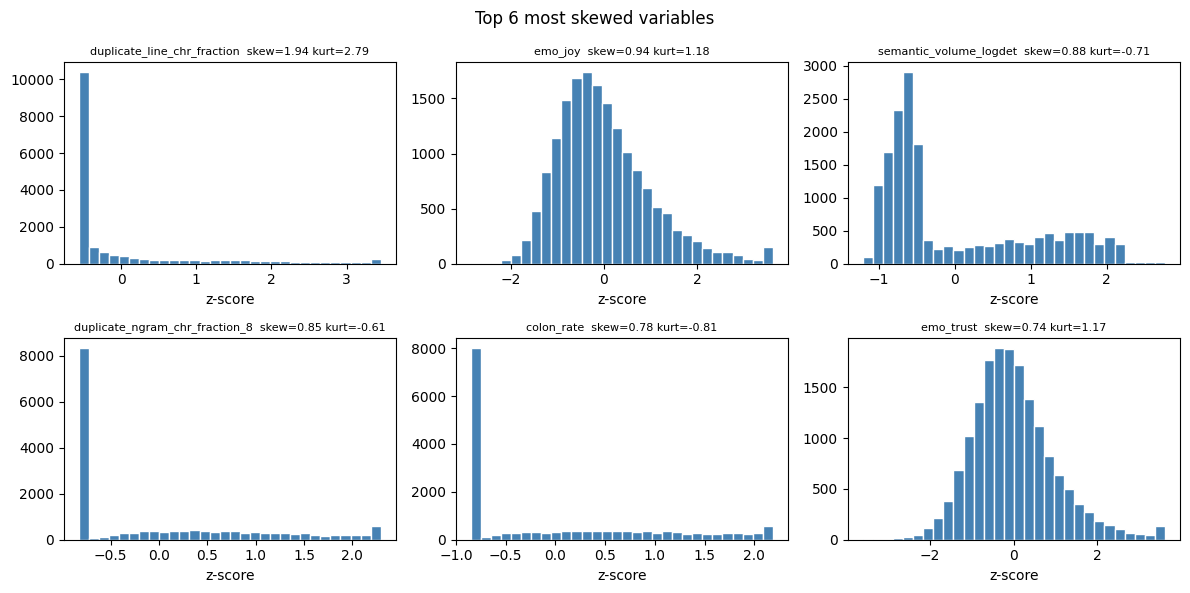

In [21]:
top_vars = norm_df.head(min(6, len(norm_df))).index.tolist()
idx_map  = {c: i for i, c in enumerate(feature_cols)}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for ax, col in zip(axes, top_vars):
    ax.hist(scaled_metrics[:, idx_map[col]], bins=30, color='steelblue', edgecolor='white')
    skew_val = norm_df.loc[col, 'skewness']
    kurt_val = norm_df.loc[col, 'kurtosis']
    ax.set_title(f'{col}  skew={skew_val:.2f} kurt={kurt_val:.2f}', fontsize=8)
    ax.set_xlabel('z-score')
for ax in axes[len(top_vars):]:
    ax.set_visible(False)
plt.suptitle('Top 6 most skewed variables')
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_norm_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Yeo-Johnson transform + drop sparse POS tags

Drop near-zero sparse POS categories (`pos_prop_X`, `pos_prop_NUM`, `pos_prop_INTJ`) these are noise in a prose corpus and do not transform to normality because >90 % of values are zero
Yeo-Johnson all remaining flagged variables (handles zeros, negatives, and both skew directions) Applied to raw `feat_df` before z-scoring so the correlation matrix is built on transformed values

This cell overwrites `keep_cols`, `scaled_metrics`, `scaled_clean`, and `corr_clean` so all downstream cells use the transformed data.

In [22]:
META_COLS = ['id']

def show_extreme_texts(col, n=50, largest=True):
    """List the observations with the most extreme raw values for `col`, by metadata only (no text content)."""
    raw = all_metrics[col] if col in all_metrics.columns else feat_df[col]
    top = raw.nlargest(n) if largest else raw.nsmallest(n)
    direction = 'largest' if largest else 'smallest'
    print(f"Top {n} {direction} raw values for '{col}'\n")
    for rank, (idx, val) in enumerate(top.items(), 1):
        row = all_metrics.loc[idx]
        print(f"{'─'*60}")
        print(f"Rank {rank}  |  {col} = {val:.4f}")
        for c in META_COLS:
            if c in all_metrics.columns:
                print(f"  {c}: {row[c]}")
        print()

show_extreme_texts('token_length_std', n=100)


Top 100 largest raw values for 'token_length_std'

────────────────────────────────────────────────────────────
Rank 1  |  token_length_std = 3.5000
  id: 47553418

────────────────────────────────────────────────────────────
Rank 2  |  token_length_std = 3.5000
  id: 55056760

────────────────────────────────────────────────────────────
Rank 3  |  token_length_std = 3.5000
  id: 59624653

────────────────────────────────────────────────────────────
Rank 4  |  token_length_std = 3.5000
  id: 47086303

────────────────────────────────────────────────────────────
Rank 5  |  token_length_std = 3.5000
  id: 46196326

────────────────────────────────────────────────────────────
Rank 6  |  token_length_std = 3.5000
  id: 57928288

────────────────────────────────────────────────────────────
Rank 7  |  token_length_std = 3.5000
  id: 58203640

────────────────────────────────────────────────────────────
Rank 8  |  token_length_std = 3.5000
  id: 54992839

─────────────────────────────────────

In [23]:
# Near-zero sparse POS tags (>90% zero) cannot be normalized — drop rather than transform
drop_nonnormal = {'pos_prop_X', 'pos_prop_SYM', 'token_length_median'}

flagged_names = set(flagged.index)
to_transform  = [c for c in flagged_names
                 if c not in drop_nonnormal and c in feat_df.columns]

print(f"Dropping (sparse, untransformable) : {sorted(drop_nonnormal & set(keep_cols))}")
print(f"Yeo-Johnson transform applied to   : {len(to_transform)} variable(s)")

# Transform raw feat_df, then re-scale
feat_yj = feat_df.copy()
if to_transform:
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    feat_yj[to_transform] = pt.fit_transform(feat_df[to_transform])
else:
    print("Nothing flagged - feature set is already normalized (e.g. running on the "
          "anonymized fallback data, which was already Yeo-Johnson transformed upstream).")

# Update shared state (overwrites variables used by downstream cells)
to_drop        = to_drop | drop_nonnormal
keep_cols      = [c for c in feature_cols if c not in to_drop]
keep_idx       = [feature_cols.index(c) for c in keep_cols]
category_clean = {c: final_category_map[c] for c in keep_cols}

scaled_metrics, scaler = scale_metrics(feat_yj)
scaled_clean           = scaled_metrics[:, keep_idx]
corr_clean             = np.corrcoef(scaled_clean, rowvar=False)

print(f"\nFinal variable count: {len(keep_cols)}")

# Re-check normality
norm_df2 = pd.DataFrame({
    'skewness': stats.skew(scaled_clean),
    'kurtosis': stats.kurtosis(scaled_clean),
}, index=keep_cols).sort_values('skewness', key=abs, ascending=False)

flagged2 = norm_df2[(norm_df2['skewness'].abs() > 2) | (norm_df2['kurtosis'].abs() > 7)]
print(f"\nVariables still flagged after transform (|skew|>2 or |kurt|>7): {len(flagged2)}")
print(flagged2.to_string())

write_table(norm_df2, RESULTS_DIR / 'normality_after_transform.csv')

Dropping (sparse, untransformable) : []
Yeo-Johnson transform applied to   : 0 variable(s)
Nothing flagged - feature set is already normalized (e.g. running on the anonymized fallback data, which was already Yeo-Johnson transformed upstream).

Final variable count: 65

Variables still flagged after transform (|skew|>2 or |kurt|>7): 0
Empty DataFrame
Columns: [skewness, kurtosis]
Index: []


## 4. Outliers

Per-variable z-scores: flag observations where any variable has `|z| > 3.5`.  
Since `scaled_metrics` is already standardised, each column is directly on the z-score scale.

In [24]:
z_max        = np.abs(scaled_clean).max(axis=1)
outlier_mask = z_max > 3.5
n_out        = int(outlier_mask.sum())
print(f'Observations with any |z| > 3.5: {n_out} ({100 * n_out / n_obs:.1f}%)')

if n_out > 0:
    out_idx   = np.where(outlier_mask)[0]
    worst_var = [keep_cols[np.abs(scaled_clean[i]).argmax()] for i in out_idx]
    out_df    = meta_full.iloc[out_idx].copy().reset_index(drop=True)
    out_df['max_z']          = z_max[outlier_mask]
    out_df['worst_variable'] = worst_var
    print(out_df.sort_values('max_z', ascending=False).to_string())

Observations with any |z| > 3.5: 1554 (9.2%)
            id                                                                                                                                                                                                                                                      title                author                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [25]:
WINSOR_THRESH  = 3.5
n_clipped      = int((np.abs(scaled_clean) > WINSOR_THRESH).sum())
max_z_before   = float(np.abs(scaled_clean).max())
scaled_clean   = np.clip(scaled_clean, -WINSOR_THRESH, WINSOR_THRESH)
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

print(f"Winsorisation")
print(f"Threshold          : ±{WINSOR_THRESH} SD")
print(f"Values clipped     : {n_clipped}  (across {n_out} flagged observations)")
print(f"Max |z| before     : {max_z_before:.2f}")
print(f"Max |z| after      : {np.abs(scaled_clean).max():.2f}")
print(f"scaled_clean and corr_clean updated — proceed to KMO")

Winsorisation
Threshold          : ±3.5 SD
Values clipped     : 3014  (across 1554 flagged observations)
Max |z| before     : 3.93
Max |z| after      : 3.50
scaled_clean and corr_clean updated — proceed to KMO


In [26]:
det_clean = np.linalg.det(corr_clean)
print(f"Variables after all assumptions besides KMO and Bartlett's tested : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")

Variables after all assumptions besides KMO and Bartlett's tested : 65
Determinant (cleaned matrix)            : 1.88e-22


## 5. KMO & Bartlett's test

- Overall KMO >= 0.60 (adequate) / >= 0.80 (good)  
- Bartlett p < 0.05: correlation matrix is not an identity matrix  
- Per-variable MSA >= 0.50: items below this are candidates for removal

In [27]:
kmo_all, kmo_model = calculate_kmo(scaled_clean)
chi2, p_val        = calculate_bartlett_sphericity(scaled_clean)
bart_df             = len(keep_cols) * (len(keep_cols) - 1) // 2

kmo_pass  = 'PASS' if kmo_model >= 0.6 else 'FAIL — need >=0.60'
bart_pass = 'PASS' if p_val < 0.05     else 'FAIL — need p<0.05'
print(f'Overall KMO     : {kmo_model:.3f}  ({kmo_pass})')
print(f"Bartlett's test  : chi2({bart_df}) = {chi2:.2f}, p = {p_val:.3e}  ({bart_pass})")

msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
low_msa    = msa_series[msa_series < 0.5]
print(f'\nPer-variable MSA < 0.50: {len(low_msa)} variable(s)')
if not low_msa.empty:
    print(low_msa.to_string())

Overall KMO     : 0.820  (PASS)
Bartlett's test  : chi2(2080) = 847542.24, p = 0.000e+00  (PASS)

Per-variable MSA < 0.50: 0 variable(s)


### Iterative MSA-based pruning

Per-variable MSA is relative to whichever other variables are still in the matrix  dropping the worst one can pull the others back above 0.50, especially for compositional families like POS proportions. Drop the single worst-MSA variable, recompute KMO/MSA on what's left, and repeat until none remain flagged.

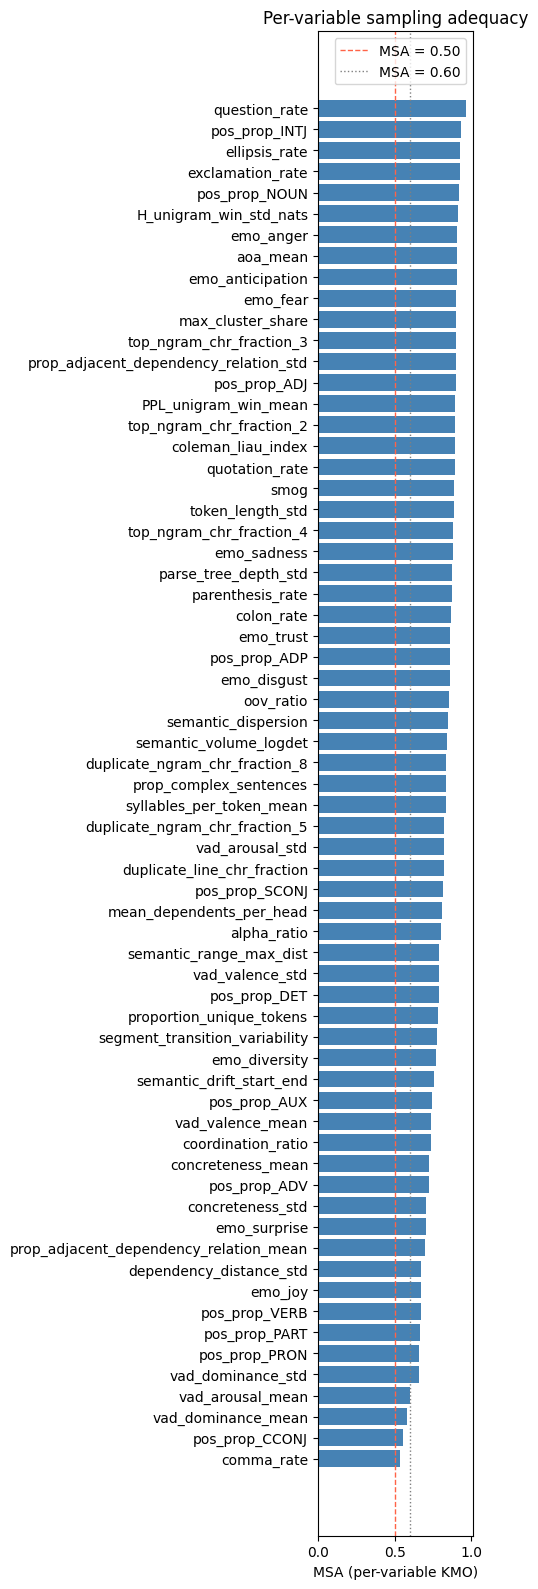

In [28]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'noalpharatio_efa_msa.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
msa_drop_log = []
while True:
    kmo_all, kmo_model = calculate_kmo(scaled_clean)
    msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
    low_msa    = msa_series[msa_series < 0.5]
    if low_msa.empty:
        break

    worst_var = low_msa.index[0]
    worst_msa = low_msa.iloc[0]
    print(f"Dropping {worst_var:<25}  (MSA={worst_msa:.3f}, overall KMO={kmo_model:.3f})")
    msa_drop_log.append({'variable': worst_var, 'msa': round(worst_msa, 3), 'kmo_before_drop': round(kmo_model, 3)})

    drop_idx     = keep_cols.index(worst_var)
    keep_cols    = [c for c in keep_cols if c != worst_var]
    scaled_clean = np.delete(scaled_clean, drop_idx, axis=1)
    to_drop.add(worst_var)

keep_idx       = [feature_cols.index(c) for c in keep_cols]
category_clean = {c: final_category_map[c] for c in keep_cols}
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

print(f"\nVariables dropped for low MSA : {len(msa_drop_log)}")
print(f"Final variable count          : {len(keep_cols)}")
print(f"Final overall KMO             : {kmo_model:.3f}")

msa_drop_df = pd.DataFrame(msa_drop_log)
write_table(msa_drop_df, RESULTS_DIR / 'msa_iterative_drop_log.csv')


Variables dropped for low MSA : 0
Final variable count          : 65
Final overall KMO             : 0.820


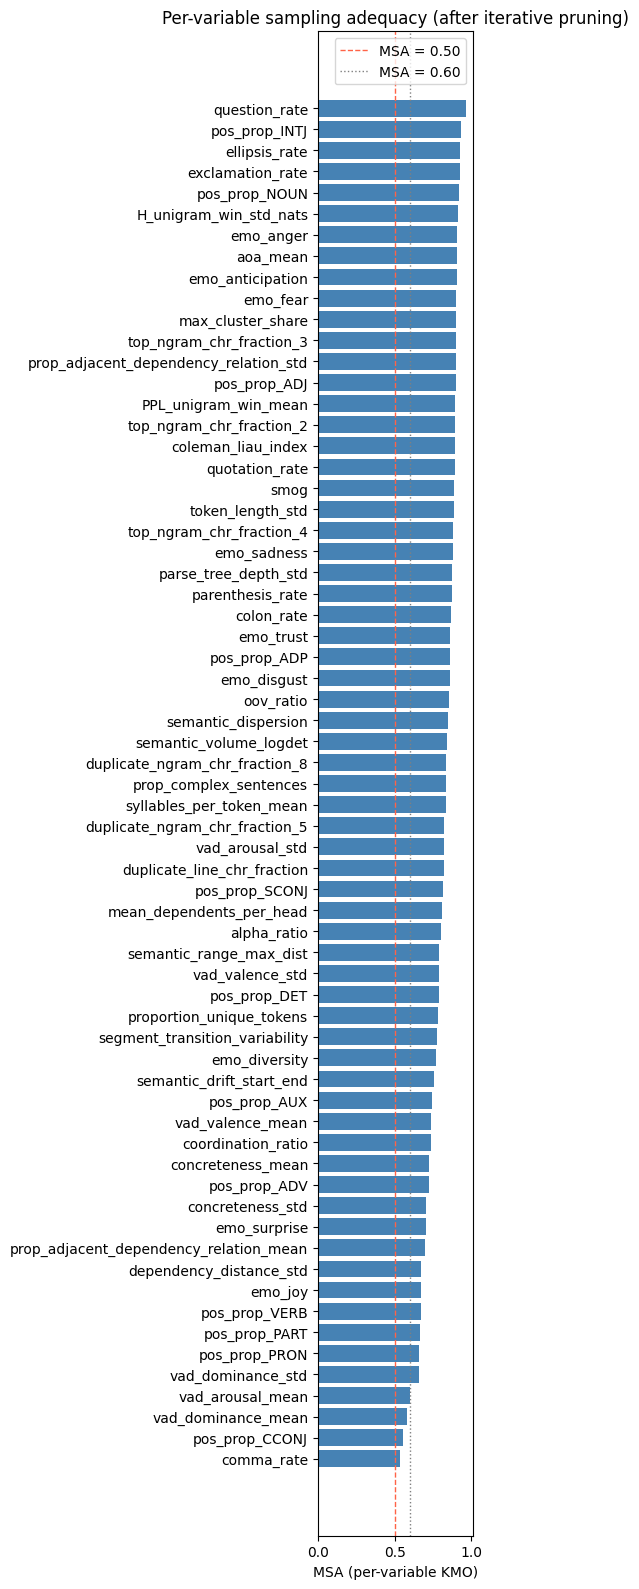

In [30]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy (after iterative pruning)')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_msa_after_pruning.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
kmo_all_final, kmo_model_final = calculate_kmo(scaled_clean)
chi2_final, p_val_final        = calculate_bartlett_sphericity(scaled_clean)
bart_df_final                  = len(keep_cols) * (len(keep_cols) - 1) // 2
det_clean                      = np.linalg.det(corr_clean)

print(f"Variables after all assumptions tested : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")
print(f"Final overall KMO                       : {kmo_model_final:.3f}")
print(f"Final Bartlett's test                   : chi2({bart_df_final}) = {chi2_final:.2f}, p = {p_val_final:.3e}")

Variables after all assumptions tested : 65
Determinant (cleaned matrix)            : 1.88e-22
Final overall KMO                       : 0.820
Final Bartlett's test                   : chi2(2080) = 847542.24, p = 0.000e+00


In [32]:
# Checkpoint for downstream notebooks (e.g. fit_efa_AO3.ipynb): load this
# file via joblib.load(STATE_PATH) to skip re-running sections 1-5 above.
STATE_PATH = PROJECT_ROOT / 'data' / 'efa_state.joblib'

joblib.dump({
    'scaled_metrics':     scaled_metrics,
    'scaled_clean':       scaled_clean,
    'corr_clean':         corr_clean,
    'feature_cols':       feature_cols,
    'keep_cols':          keep_cols,
    'final_category_map': final_category_map,
    'category_clean':     category_clean,
    'n_obs':              n_obs,
    'n_vars':             n_vars,
    'meta_full':          meta_full,
    'used_fallback':      IN_FP == _FALLBACK_FP,
}, STATE_PATH)

print(f"Saved → {STATE_PATH.relative_to(PROJECT_ROOT)}")
print(f"  scaled_metrics : {scaled_metrics.shape}  (all vars, YJ-transformed, z-scored)")
print(f"  scaled_clean   : {scaled_clean.shape}  ({len(keep_cols)} vars, winsorized)")
print(f"  meta_full      : {meta_full.shape}  (same row order as scaled_metrics/scaled_clean)")

Saved → data/efa_state.joblib
  scaled_metrics : (16966, 71)  (all vars, YJ-transformed, z-scored)
  scaled_clean   : (16966, 65)  (65 vars, winsorized)
  meta_full      : (16966, 25)  (same row order as scaled_metrics/scaled_clean)
